# Tsuboyama 2023 mega-scale stability — schema & data prep

Prepares the reward targets and DPO preference pairs for the **RL-ESM** project from the
[Tsuboyama et al. 2023](https://www.nature.com/articles/s41586-023-06328-6) mega-scale
folding-stability dataset (Zenodo record `7992926`).

**Source of truth:** `data/tsuboyama/Tsuboyama2023_Dataset2_Dataset3_20230416.csv`
(776k rows). This is the ML-processed table with amino-acid sequences and folding ΔG —
the one ProteinDPO / ESM use. `Dataset1` is DNA-only with no `aa_seq`, so we skip it.

> Run `pixi run python data/download.py --dataset tsuboyama --match Processed_K50_dG_datasets`
> and unzip first (see README "Reproduce" section). This notebook mirrors the logic in
> `data/prepare.py --dataset tsuboyama` (the canonical, scripted entry point) for interactive
> EDA — if the two drift apart, the script is the source of truth.

## Schema (columns we use)

| column | meaning |
|---|---|
| `name` | unique id: `WT.pdb` or `WT.pdb_<MUT>` (e.g. `1A32.pdb_A45D`) |
| `aa_seq` | the assayed protein sequence (what ESM-C embeds) |
| `mut_type` | `wt`, a substitution (`A45D`), or an indel (`insG2`, `del…`) |
| `WT_name` | parent wild-type domain (groups mutants) |
| `WT_cluster` | fold/topology label (numeric = natural cluster, e.g. `EEHH`/`HHH` = de novo) |
| `dG_ML` | **folding free energy ΔG** (kcal/mol). *Censored:* `<-1`, `>5`, `-` |
| `ddG_ML` | ΔΔG of the mutation vs its WT (same censoring) |
| `Stabilizing_mut` | `True`/`False`/`-` |

**Censoring matters:** `<-1` = too unstable to measure, `>5` = too stable. Naive
`float()` drops ~100k rows. We map the bounds to their limits instead.

## Load

In [1]:
import warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA = Path("../data/tsuboyama")
CSV = DATA / "Tsuboyama2023_Dataset2_Dataset3_20230416.csv"
assert CSV.exists(), f"missing {CSV} -- download + unzip Processed_K50_dG_datasets.zip"
print("csv:", CSV.name, f"({CSV.stat().st_size/1e6:.0f} MB)")

csv: Tsuboyama2023_Dataset2_Dataset3_20230416.csv (698 MB)


In [2]:
USECOLS = ["name","aa_seq","mut_type","WT_name","WT_cluster",
           "dG_ML","ddG_ML","Stabilizing_mut"]


# TODO know what mut type wt ?,see whats there in pdb files

def parse_dG(x):
    """Parse censored ML folding stabilities to floats."""
    if x == "<-1": return -1.0   # unmeasurably unstable -> lower bound
    if x == ">5":  return 5.0    # unmeasurably stable   -> upper bound
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan            # "-" and blanks -> missing

# low_memory=False: single-pass read. The default chunked reader hits a pandas
# IndexError on the mixed-dtype columns WT_cluster (ints+codes) and dG_ML (floats+"<-1").
df = pd.read_csv(CSV, usecols=USECOLS, low_memory=False)
df["dG"]  = df["dG_ML"].map(parse_dG)
df["ddG"] = df["ddG_ML"].map(parse_dG)
df["WT_cluster"] = df["WT_cluster"].astype(str)
df["is_wt"] = df["mut_type"].eq("wt")

print("rows:", len(df), "| mem MB:", round(df.memory_usage(deep=True).sum()/1e6, 1))
print("dG missing:", int(df.dG.isna().sum()),
      "| censored <-1:", int((df.dG_ML == "<-1").sum()),
      "| censored >5:", int((df.dG_ML == ">5").sum()))
df.head(3)

rows: 776298 | mem MB: 419.1
dG missing: 4537 | censored <-1: 53235 | censored >5: 43059


,name,aa_seq,mut_type,WT_name,WT_cluster,dG_ML,ddG_ML,Stabilizing_mut,dG,ddG,is_wt
0,EA|run2_0325_0005.pdb,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.3321258839433834,0.01719762915616707,False,3.332126,0.017198,True
1,EA|run2_0325_0005.pdb_wtm,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.3998316632160224,0.08490340842880606,False,3.399832,0.084903,True
2,EA|run2_0325_0005.pdb_wte,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.315782210420261,0.0008539556330444675,False,3.315782,0.000854,True


In [11]:
df['WT_cluster'].value_counts()

WT_cluster
15       88029
23       39432
EEHH     39361
4        38485
EEHEE    27752
         ...  
75         872
166        863
219        859
209        832
123        784
Name: count, Length: 133, dtype: int64

## Exploratory stats

In [3]:
def mut_class(m):
    m = str(m)
    if m == "wt": return "wt"
    if m.startswith("ins"): return "insertion"
    if m.startswith("del"): return "deletion"
    return "substitution"

print("WT proteins:", df.WT_name.nunique())
print("\nmutation types:")
print(df.mut_type.map(mut_class).value_counts())
print("\nStabilizing_mut:", df.Stabilizing_mut.value_counts().to_dict())

# natural vs de novo: de novo domains carry a topology-code cluster
# (EEHH, HHH, EHEE, HEEH, EEHEE, hall); natural domains a numeric cluster id.
df["origin"] = np.where(df.WT_cluster.str.fullmatch(r"\d+"), "natural", "de_novo")
by_origin = df.drop_duplicates("WT_name").origin.value_counts().to_dict()
print(f"\nWT domains -> natural={by_origin.get('natural')}  de_novo={by_origin.get('de_novo')}  (paper: 331 + 148)")
print("de novo topologies:", sorted(df.loc[df.origin=='de_novo','WT_cluster'].unique()))
print("rows by origin:", df.origin.value_counts().to_dict())

WT proteins: 479

mutation types:
mut_type
substitution    698032
insertion        50643
deletion         25275
wt                2348
Name: count, dtype: int64

Stabilizing_mut: {'False': 579808, '-': 193556, 'True': 2934}

WT domains -> natural=331  de_novo=148  (paper: 331 + 148)
de novo topologies: ['EEHEE', 'EEHH', 'EHEE', 'HEEH', 'HHH', 'hall']
rows by origin: {'natural': 626120, 'de_novo': 150178}


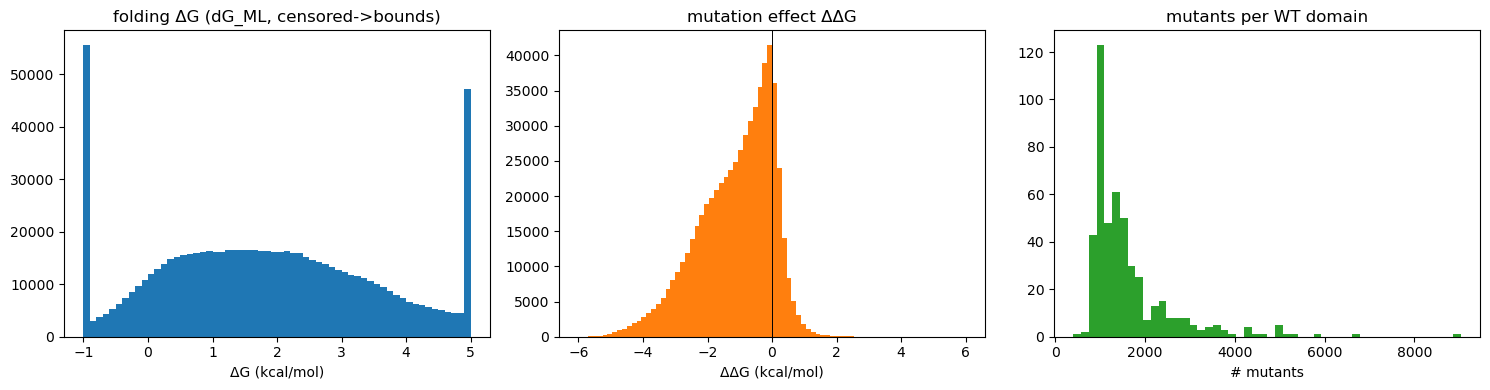

aa_seq length: min 31  median 58  max 75


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df.dG.dropna(), bins=60, color="C0")
ax[0].set_title("folding ΔG (dG_ML, censored->bounds)"); ax[0].set_xlabel("ΔG (kcal/mol)")

ddg = df.loc[~df.is_wt, "ddG"].dropna()
ax[1].hist(ddg, bins=80, range=(-6, 6), color="C1")
ax[1].axvline(0, color="k", lw=.7)
ax[1].set_title("mutation effect ΔΔG"); ax[1].set_xlabel("ΔΔG (kcal/mol)")

per_wt = df[~df.is_wt].groupby("WT_name").size()
ax[2].hist(per_wt, bins=50, color="C2")
ax[2].set_title("mutants per WT domain"); ax[2].set_xlabel("# mutants")
plt.tight_layout(); plt.show()
print("aa_seq length: min %d  median %d  max %d" % (
    df.aa_seq.str.len().min(), int(df.aa_seq.str.len().median()), df.aa_seq.str.len().max()))

## Map to the RL project

- **Reward target** — `aa_seq -> dG` (folding stability). Fit the ridge probe / regression
  reward on this. `ddG` is the mutation-effect label if you prefer a relative reward.
- **DPO preference pairs** — within each WT domain, a higher-ΔG variant is *preferred* over
  a lower-ΔG one (margin filter for confident pairs).
- **Held-out split** — reserve the **de novo** domains for evaluation (leakage-free: not in
  ESM/ESMFold pretraining). Build reward + pairs from **natural** domains only.

In [5]:
OUT = Path("../data/prepared"); OUT.mkdir(parents=True, exist_ok=True)

# reward table: keep rows with a measured dG; carry origin so we can honour the split
reward = (df[df.dG.notna()]
          .loc[:, ["name","WT_name","origin","WT_cluster","mut_type","is_wt","aa_seq","dG","ddG"]]
          .reset_index(drop=True))
reward.to_csv(OUT/"reward_table.csv", index=False)
print("reward rows:", len(reward), "->", OUT/"reward_table.csv")
reward.head(3)

reward rows: 771761 -> ../data/prepared/reward_table.csv


,name,WT_name,origin,WT_cluster,mut_type,is_wt,aa_seq,dG,ddG
0,EA|run2_0325_0005.pdb,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.332126,0.017198
1,EA|run2_0325_0005.pdb_wtm,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.399832,0.084903
2,EA|run2_0325_0005.pdb_wte,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.315782,0.000854


In [6]:
# DPO preference pairs -- NATURAL domains only (de novo is held out for eval) is random startegry best ?
rng = np.random.default_rng(0)
MARGIN = 1.0            # kcal/mol: min ΔG gap for a confident preference
MAX_PAIRS_PER_WT = 200

train = reward[reward.origin == "natural"]
pairs = []
for wt, g in train.groupby("WT_name"):
    seqs, dGs = g.aa_seq.to_numpy(), g.dG.to_numpy()
    n = len(g)
    if n < 2: continue
    cand = rng.integers(0, n, size=(min(MAX_PAIRS_PER_WT * 6, n * n), 2))
    cand = cand[cand[:, 0] != cand[:, 1]]
    kept = 0
    for i, j in cand:
        if abs(dGs[i] - dGs[j]) < MARGIN: continue
        hi, lo = (i, j) if dGs[i] > dGs[j] else (j, i)
        pairs.append((wt, seqs[hi], seqs[lo], float(dGs[hi]), float(dGs[lo])))
        kept += 1
        if kept >= MAX_PAIRS_PER_WT: break

dpo = pd.DataFrame(pairs, columns=["WT_name","chosen","rejected","dG_chosen","dG_rejected"])
dpo.to_csv(OUT/"dpo_pairs.csv", index=False)
print(f"DPO pairs: {len(dpo)} across {dpo.WT_name.nunique()} natural domains -> {OUT/'dpo_pairs.csv'}")
dpo.head(3)

DPO pairs: 66012 across 331 natural domains -> ../data/prepared/dpo_pairs.csv


,WT_name,chosen,rejected,dG_chosen,dG_rejected
0,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGCKFQILNSSEGDWWEARLLTTGE...,VTLFVALYDYEARTEDDLSFHKGWKFQILNSSEGDWWEARPLTTGE...,3.680976,0.840615
1,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGQKFQILNSSEGDWWEARWLTTGE...,VTLFVALYDYEARTEDDLSFHKGKKFQILNSSEGDWWEARQLTTGE...,2.296087,0.620317
2,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGHKFQILNSSEGDWWEARSLTTGE...,VTLFVALYDYEARTEDDLSFHKGWKFQILNSSEGDWWEARDLTTGE...,4.172556,2.451153


## Structural (Foldseek) split — ESM3 paper method [optional]

The `origin` column above (natural vs. de novo) is a simple split — but it doesn't rule
out two *structurally near-identical* domains landing in different splits (e.g. two de novo
designs from the same topology run, or two solved structures of the same well-studied
natural fold). The ESM3 paper (App. A.1.4.4, [`docs/esm3.txt:2170-2253`](../docs/esm3.txt))
instead clusters all domain structures with Foldseek (`easy-cluster -c 0.5`) and keeps
clusters intact across train/val/test.

`data/foldseek_split.py` implements this and writes **two variants** of the train side
(val/test are identical between them — both come from the same singleton-cluster pool):

- **representative** (`wt_split_foldseek.csv`, paper-exact): each non-singleton cluster
  contributes **one** representative domain to train; the rest are **excluded**. Faithful to
  the paper, but ~75% of domains end up excluded here — a few structural clusters are huge
  (e.g. 50 near-identical natural-fold structures, or a de novo design campaign that explored
  one topology dozens of times), and only 1 member of each survives.
- **full** (`wt_split_foldseek_full.csv`): every domain in a non-singleton cluster goes to
  train instead of being dropped. Still zero train/eval leakage (the redundancy is *within*
  train, not between train and eval) — just keeps the data DPO/RL training benefits from.

**⚠️ These two are origin-agnostic and break the pretraining-leakage guarantee above.**
Foldseek doesn't know natural from de novo — 93% of de novo domains fall into (mostly
all-de-novo) non-singleton clusters and get pulled into **train**, and `test` ends up a
natural+de-novo mix. That's fine for the paper's original goal (no near-duplicate structural
memorization) but it silently defeats the *other* guarantee this project relies on: de novo
domains are held out because they can't be in ESM-C's pretraining corpus, so scoring on them
tests generalization beyond pretraining memorization, not just beyond this dataset's own
redundancy. **Don't use these two if that guarantee matters** (e.g. for the reward-probe gate
or DPO's held-out eval below).

For that, `data/foldseek_split.py` also writes two **denovo-safe** variants: every de novo
domain is forced to `test` (exactly the same 148 as the `origin` split above), any natural
domain that structurally clusters with a de novo domain is excluded (it'd be a near-duplicate
of a test example), and the remaining pure-natural clusters get the same
representative/full treatment:

- `wt_split_foldseek_denovo_safe.csv` (representative)
- `wt_split_foldseek_full_denovo_safe.csv` (full)

Run once via:
```
pixi run python data/download.py --dataset tsuboyama --match AlphaFold_model_PDBs
pixi run python data/foldseek_split.py --stratify-pppl
```
The cells below load and compare all four outputs.

In [7]:
FS_REP  = OUT / "wt_split_foldseek.csv"
FS_FULL = OUT / "wt_split_foldseek_full.csv"
assert FS_REP.exists() and FS_FULL.exists(), \
    "missing -- run: pixi run python data/foldseek_split.py --stratify-pppl"

fs_rep  = pd.read_csv(FS_REP)
fs_full = pd.read_csv(FS_FULL)

print("representative:", fs_rep.split.value_counts().to_dict())
print("full:          ", fs_full.split.value_counts().to_dict())
print(f"\n{fs_rep.WT_name.nunique()} domains -> {fs_rep.foldseek_cluster.nunique()} structural clusters")

val_test_rep  = fs_rep[fs_rep.split.isin(["val", "test"])].set_index("WT_name").split
val_test_full = fs_full[fs_full.split.isin(["val", "test"])].set_index("WT_name").split
print("val/test identical between variants:", val_test_rep.equals(val_test_full.reindex(val_test_rep.index)))

print("\nrepresentative: split x origin:")
print(fs_rep.groupby(["split", "origin"]).size().unstack(fill_value=0))
print("\nfull: split x origin:")
print(fs_full.groupby(["split", "origin"]).size().unstack(fill_value=0))

if "pppl_bin" in fs_rep.columns:
    print("\nrepresentative: pppl_bin x split:")
    print(fs_rep.groupby(["split", "pppl_bin"]).size().unstack(fill_value=0))
fs_rep.head()

representative: {'excluded': 361, 'train': 54, 'test': 52, 'val': 12}
full:           {'train': 415, 'test': 52, 'val': 12}

479 domains -> 118 structural clusters
val/test identical between variants: True

representative: split x origin:
origin    de_novo  natural
split                     
excluded      122      239
test           10       42
train          16       38
val             0       12

full: split x origin:
origin  de_novo  natural
split                   
test         10       42
train       138      277
val           0       12

representative: pppl_bin x split:
pppl_bin  high  low  medium
split                      
excluded   109   31     221
test        22    0      30
train       14    9      31
val          5    0       7


,WT_name,origin,WT_cluster,foldseek_cluster,cluster_size,pppl,pppl_bin,split
0,EA|run2_0325_0005.pdb,de_novo,EEHH,EA:run3_1331_0004,34,9.235145,high,train
1,EA|run7_1025_0001.pdb,de_novo,EEHH,EA:run3_1331_0004,34,8.256751,high,excluded
2,2KRS.pdb_W42A,natural,44,2KT8,9,4.083685,medium,excluded
3,1Y0M.pdb,natural,15,1TUC,4,4.484600,medium,excluded
4,5GU9.pdb,natural,226,5GU9,3,2.665838,medium,train


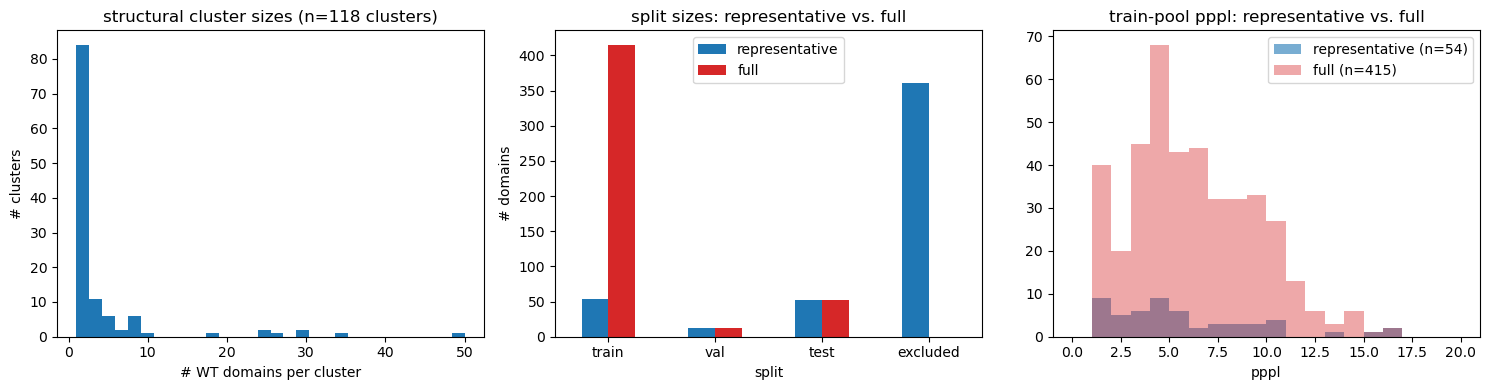


vs. the plain origin split (natural/de novo, {'natural': 331, 'de_novo': 148}):
both foldseek variants enforce structural non-leakage between train and val/test;
'representative' additionally de-duplicates train (paper-exact), 'full' keeps every
redundant domain -- note the full variant's train pppl distribution is skewed toward
whatever bin the largest clusters happen to fall in, since each cluster's domains all
share ~the same pppl.


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

cluster_sizes = fs_rep.drop_duplicates("foldseek_cluster").cluster_size
ax[0].hist(cluster_sizes, bins=30, color="C0")
ax[0].set_title(f"structural cluster sizes (n={len(cluster_sizes)} clusters)")
ax[0].set_xlabel("# WT domains per cluster"); ax[0].set_ylabel("# clusters")

counts = pd.DataFrame({
    "representative": fs_rep.split.value_counts(),
    "full": fs_full.split.value_counts(),
}).reindex(["train", "val", "test", "excluded"]).fillna(0)
counts.plot(kind="bar", ax=ax[1], color=["C0", "C3"])
ax[1].set_title("split sizes: representative vs. full")
ax[1].set_ylabel("# domains"); ax[1].tick_params(axis="x", rotation=0)

if "pppl" in fs_rep.columns:
    rep_train, full_train = fs_rep[fs_rep.split == "train"], fs_full[fs_full.split == "train"]
    ax[2].hist(rep_train.pppl, bins=20, range=(0, 20), alpha=0.6, color="C0",
               label=f"representative (n={len(rep_train)})")
    ax[2].hist(full_train.pppl, bins=20, range=(0, 20), alpha=0.4, color="C3",
               label=f"full (n={len(full_train)})")
    ax[2].set_title("train-pool pppl: representative vs. full")
    ax[2].set_xlabel("pppl"); ax[2].legend()
else:
    ax[2].axis("off")
    ax[2].text(0.5, 0.5, "run --stratify-pppl to populate pppl", ha="center")
plt.tight_layout(); plt.show()

origin_counts = df.drop_duplicates("WT_name").origin.value_counts().to_dict()
print(f"\nvs. the plain origin split (natural/de novo, {origin_counts}):")
print("both foldseek variants enforce structural non-leakage between train and val/test;")
print("'representative' additionally de-duplicates train (paper-exact), 'full' keeps every")
print("redundant domain -- note the full variant's train pppl distribution is skewed toward")
print("whatever bin the largest clusters happen to fall in, since each cluster's domains all")
print("share ~the same pppl.")

In [9]:
DS_REP  = OUT / "wt_split_foldseek_denovo_safe.csv"
DS_FULL = OUT / "wt_split_foldseek_full_denovo_safe.csv"
assert DS_REP.exists() and DS_FULL.exists(), \
    "missing -- run: pixi run python data/foldseek_split.py --stratify-pppl"

ds_rep  = pd.read_csv(DS_REP)
ds_full = pd.read_csv(DS_FULL)

print("denovo-safe representative:", ds_rep.split.value_counts().to_dict())
print("denovo-safe full:          ", ds_full.split.value_counts().to_dict())

denovo_names = set(df[df.origin == "de_novo"].WT_name)
for name, ds in [("representative", ds_rep), ("full", ds_full)]:
    test_names = set(ds[ds.split == "test"].WT_name)
    train_or_val_names = set(ds[ds.split.isin(["train", "val"])].WT_name)
    print(f"\n[{name}] test == all {len(denovo_names)} de novo domains:", test_names == denovo_names)
    print(f"[{name}] any de novo domain leaked into train/val:", bool(train_or_val_names & denovo_names))

print("\ndenovo-safe representative: split x origin:")
print(ds_rep.groupby(["split", "origin"]).size().unstack(fill_value=0))
print("\ndenovo-safe full: split x origin:")
print(ds_full.groupby(["split", "origin"]).size().unstack(fill_value=0))
ds_full.head()

denovo-safe representative: {'excluded': 241, 'test': 148, 'val': 54, 'train': 36}
denovo-safe full:           {'train': 267, 'test': 148, 'val': 54, 'excluded': 10}

[representative] test == all 148 de novo domains: True
[representative] any de novo domain leaked into train/val: False

[full] test == all 148 de novo domains: True
[full] any de novo domain leaked into train/val: False

denovo-safe representative: split x origin:
origin    de_novo  natural
split                     
excluded        0      241
test          148        0
train           0       36
val             0       54

denovo-safe full: split x origin:
origin    de_novo  natural
split                     
excluded        0       10
test          148        0
train           0      267
val             0       54


,WT_name,origin,WT_cluster,foldseek_cluster,cluster_size,pppl,pppl_bin,split
0,EA|run2_0325_0005.pdb,de_novo,EEHH,EA:run3_1331_0004,34,9.235145,high,test
1,EA|run7_1025_0001.pdb,de_novo,EEHH,EA:run3_1331_0004,34,8.256751,high,test
2,2KRS.pdb_W42A,natural,44,2KT8,9,4.083685,medium,train
3,1Y0M.pdb,natural,15,1TUC,4,4.484600,medium,train
4,5GU9.pdb,natural,226,5GU9,3,2.665838,medium,train


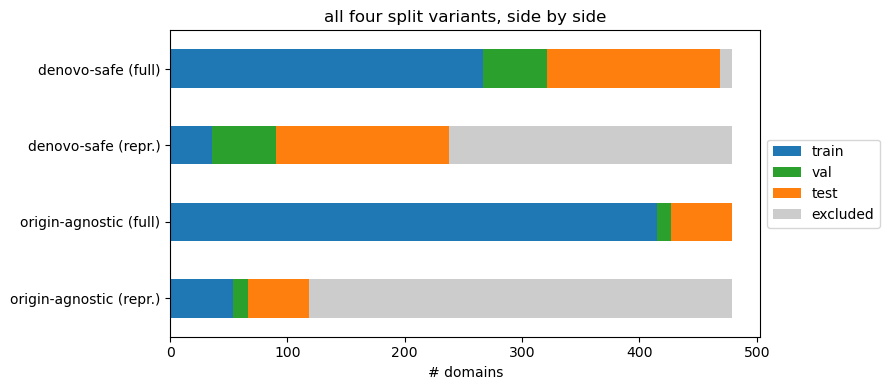

Use the plain origin split or a denovo-safe variant for anything relying on the
pretraining-leakage guarantee (reward probe gate, DPO held-out eval). Only reach for the
origin-agnostic variants if that guarantee doesn't matter for what you're testing -- they
answer a different question (structural non-redundancy within this dataset, not novelty
vs. ESM's pretraining corpus).


In [10]:
counts_all = pd.DataFrame({
    "origin-agnostic (repr.)": fs_rep.split.value_counts(),
    "origin-agnostic (full)": fs_full.split.value_counts(),
    "denovo-safe (repr.)": ds_rep.split.value_counts(),
    "denovo-safe (full)": ds_full.split.value_counts(),
}).reindex(["train", "val", "test", "excluded"]).fillna(0)

ax = counts_all.T.plot(kind="barh", stacked=True, figsize=(9, 4),
                        color={"train": "C0", "val": "C2", "test": "C1", "excluded": "0.8"})
ax.set_xlabel("# domains"); ax.set_title("all four split variants, side by side")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(); plt.show()

print(
    "Use the plain origin split or a denovo-safe variant for anything relying on the\n"
    "pretraining-leakage guarantee (reward probe gate, DPO held-out eval). Only reach for the\n"
    "origin-agnostic variants if that guarantee doesn't matter for what you're testing -- they\n"
    "answer a different question (structural non-redundancy within this dataset, not novelty\n"
    "vs. ESM's pretraining corpus)."
)

## Next steps

1. `reward/fit_probe.py` — ridge probe on frozen ESM-C penultimate embeddings of `aa_seq`
   -> `dG`, report held-out Spearman on de novo domains (**gate before any alignment**).
2. `align/train_dpo.py` — DPO on `dpo_pairs.csv`.
3. `align/train_grpo.py` — GRPO with the probe as reward.
4. Validate both on the held-out de novo domains + ProteinGym; log the reward-hacking gap.
